# Philadelphia Murals vs. Crime Rates

In [185]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import warnings
from pathlib import Path
from itertools import combinations

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

In [186]:
folders = [
    'data/maps',
    'data/crime',
    'data/murals',
    'data/greenspace',
    'data/processed',
    'outputs/greenspace',
    'outputs/murals',
    'outputs/combined',
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

In [187]:
# Check files exist
map_files = [
    'data/maps/neighborhoods.geojson',
    'data/maps/streets.geojson',
]

for f in map_files:
    assert Path(f).exists(), f"Missing file: {f}"

# Load map layers
neighborhoods = gpd.read_file('data/maps/neighborhoods.geojson')
streets = gpd.read_file('data/maps/streets.geojson')

# CRS alignment check
assert neighborhoods.crs == streets.crs, f"CRS mismatch: {neighborhoods.crs} vs {streets.crs}"

# Diagnostics
print('Neighborhoods:')
print(f'  Shape: {neighborhoods.shape}')
print(f'  CRS: {neighborhoods.crs}')
print(f'  Columns: {list(neighborhoods.columns)}')
print(f'  Invalid geometries: {(~neighborhoods.geometry.is_valid).sum()}')

print('\nStreets:')
print(f'  Shape: {streets.shape}')
print(f'  CRS: {streets.crs}')
print(f'  Columns: {list(streets.columns)}')
print(f'  Invalid geometries: {(~streets.geometry.is_valid).sum()}')

Neighborhoods:
  Shape: (159, 6)
  CRS: EPSG:4326
  Columns: ['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry']
  Invalid geometries: 0

Streets:
  Shape: (41271, 32)
  CRS: EPSG:4326
  Columns: ['fnode_', 'tnode_', 'lpoly_', 'rpoly_', 'length', 'stcl2_', 'stcl2_id', 'pre_dir', 'st_name', 'st_type', 'suf_dir', 'zip_left', 'zip_right', 'l_f_add', 'l_t_add', 'r_f_add', 'r_t_add', 'st_code', 'l_hundred', 'r_hundred', 'seg_id', 'oneway', 'class', 'responsibl', 'update_', 'newsegdate', 'multi_rep', 'streetlabe', 'stname', 'objectid', 'Shape__Length', 'geometry']
  Invalid geometries: 0


In [188]:
print(streets['class'].value_counts())

class
4     15496
5     15300
3      4507
2      4487
12      421
1       420
14      167
10      164
9       116
6        94
13       79
15       11
18        9
Name: count, dtype: int64


In [189]:
streets = streets[streets['class'].isin([1, 2, 3, 4])].reset_index(drop=True)

In [190]:
print(neighborhoods.head(10))

              NAME          LISTNAME          MAPNAME  Shape_Leng  \
0       BRIDESBURG        Bridesburg       Bridesburg    27814.55   
1        BUSTLETON         Bustleton        Bustleton    48868.46   
2       CEDARBROOK        Cedarbrook       Cedarbrook    20021.42   
3    CHESTNUT_HILL     Chestnut Hill    Chestnut Hill    56394.30   
4       EAST_FALLS        East Falls       East Falls    27400.78   
5  MOUNT_AIRY_EAST  Mount Airy, East  East Mount Airy    28845.55   
6      GRAYS_FERRY       Grays Ferry      Grays Ferry    25521.57   
7            OLNEY             Olney            Olney    32197.21   
8   PENNYPACK_PARK    Pennypack Park   Pennypack Park    87084.29   
9         SOMERTON          Somerton         Somerton    55054.58   

    Shape_Area                                           geometry  
0  44586263.60  MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4...  
1 114050423.59  MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4...  
2  24871744.63  MULTIPOLYGON (((-75.

In [191]:
# Build neighbourhood adjacency list for graph colouring
neighbors_map = {name: set() for name in neighborhoods['NAME']}

for i, j in combinations(neighborhoods.index, 2):
    geom_i = neighborhoods.loc[i, 'geometry']
    geom_j = neighborhoods.loc[j, 'geometry']
    if geom_i.touches(geom_j):
        name_i = neighborhoods.loc[i, 'NAME']
        name_j = neighborhoods.loc[j, 'NAME']
        neighbors_map[name_i].add(name_j)
        neighbors_map[name_j].add(name_i)

In [192]:
# Greedy graph colouring using grey palette
greys = [
    '#f0f0f0', '#dcdcdc', '#c8c8c8', '#b4b4b4', '#a0a0a0',
    '#8c8c8c', '#787878', '#646464', '#505050', '#3c3c3c',
    '#d2d2d2', '#bebebe'
]

color_map = {}
for name in neighborhoods['NAME']:
    used = {color_map[n] for n in neighbors_map[name] if n in color_map}
    color_map[name] = next(shade for shade in greys if shade not in used)

neighborhoods['color'] = neighborhoods['NAME'].map(color_map)

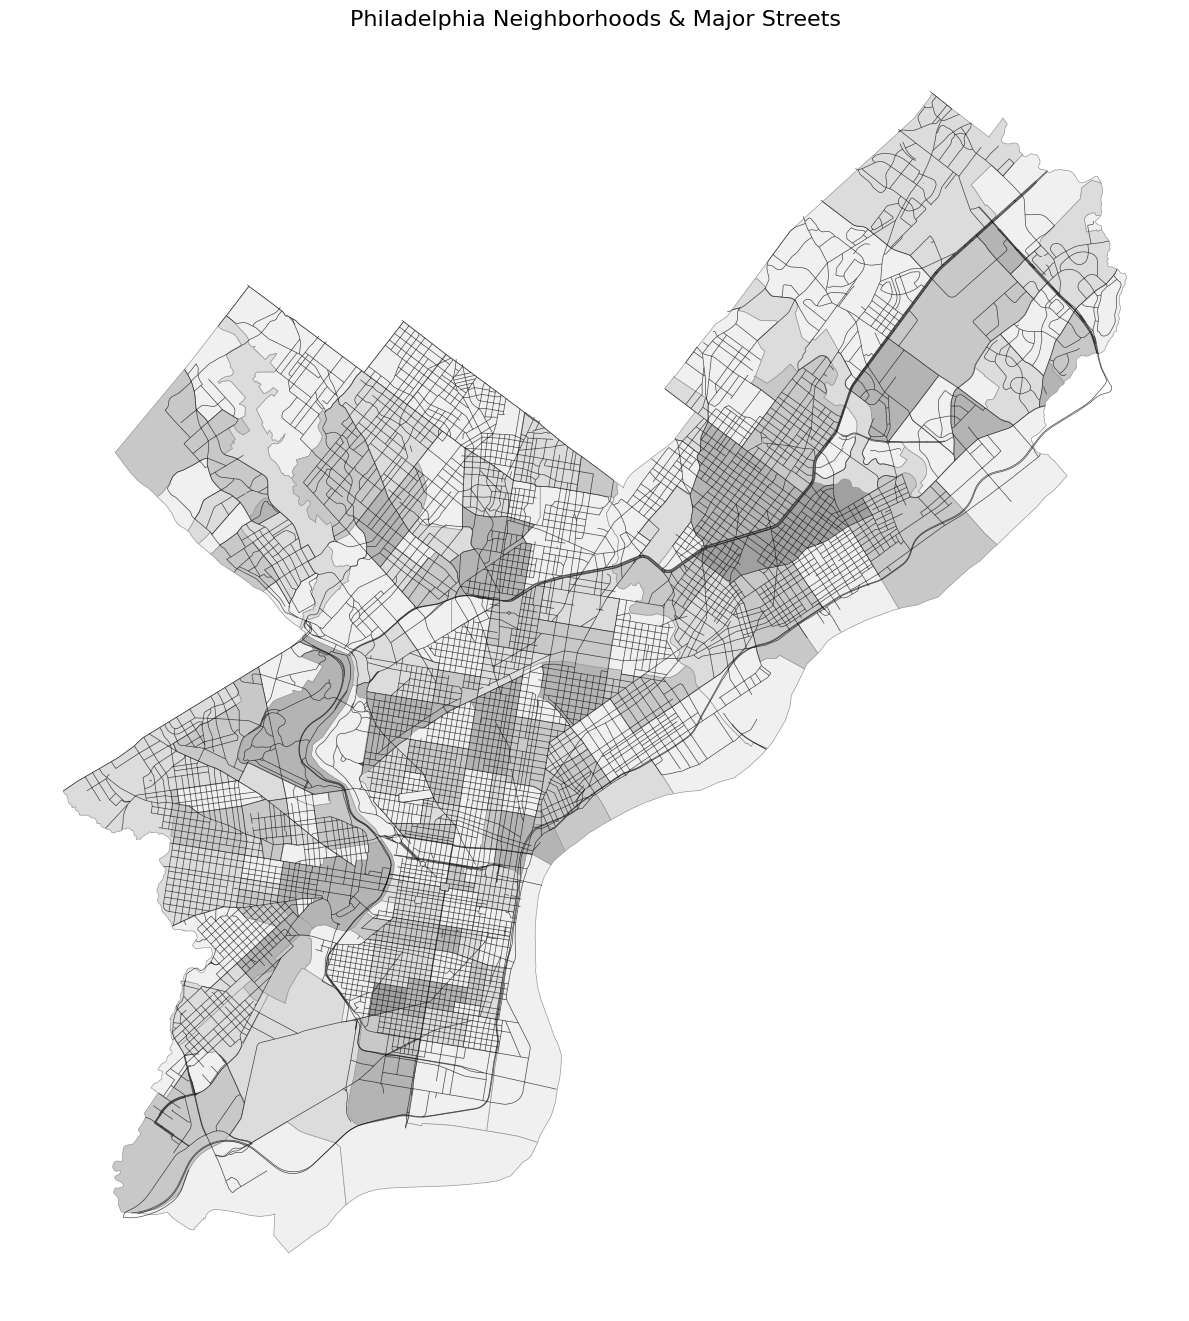

In [193]:
fig, ax = plt.subplots(figsize=(12, 14))

neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)
streets.plot(ax=ax, color='black', linewidth=0.5, alpha=0.7)

ax.set_title('Philadelphia Neighborhoods & Major Streets', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/map_base.png', dpi=150, bbox_inches='tight')
plt.show()

In [194]:
# Load murals GeoJSON
murals_gdf = gpd.read_file('data/murals/philadelphia_murals_raw.geojson')
murals_gdf = murals_gdf.to_crs(neighborhoods.crs)

print(f"Shape: {murals_gdf.shape}")
print(f"CRS: {murals_gdf.crs}")
print(f"Invalid geometries: {(~murals_gdf.geometry.is_valid).sum()}")
print(f"Null geometries: {murals_gdf.geometry.isna().sum()}")
print(f"Year created range: {murals_gdf['year_created'].min()} - {murals_gdf['year_created'].max()}")
print(f"Missing year_created: {murals_gdf['year_created'].isna().sum()}")
print(f"\nColumns:\n{list(murals_gdf.columns)}")
print(f"\nHead:\n{murals_gdf.head()}")

Shape: (1102, 6)
CRS: EPSG:4326
Invalid geometries: 0
Null geometries: 0
Year created range: 1983 - No data
Missing year_created: 0

Columns:
['mural_name', 'artist', 'address', 'year_created', 'media', 'geometry']

Head:
                                          mural_name  \
0                 100 Years at Milton Hershey School   
1                                         12:00 Noon   
2                                3 Cultures, 1 Heart   
3                                52nd Street Theatre   
4  56TH STREET GATEWAY: Life Underground and Wild...   

                        artist  \
0                  Jared Bader   
1                Frito Bastien   
2              Parris Stancell   
3           Jonathan Laidacker   
4  Kala Hagopian @HagopianArts   

                                             address year_created  \
0   E Governor Rd, Hershey, Pennsylvania, 17033, USA         2008   
1  6340 Wayne Ave, Philadelphia, Pennsylvania, 19...         2007   
2  2721 N 5th St, Philadelphi

In [195]:
# Clip to Philadelphia boundary (removes outliers with bad coordinates)
philly_boundary = neighborhoods.union_all()

print(f"Murals before clipping: {len(murals_gdf)}")
murals_gdf = murals_gdf[murals_gdf.geometry.within(philly_boundary)].reset_index(drop=True)
print(f"Murals after clipping: {len(murals_gdf)}")

murals_gdf.to_file('data/murals/philadelphia_murals.geojson', driver='GeoJSON')

Murals before clipping: 1102
Murals after clipping: 1092


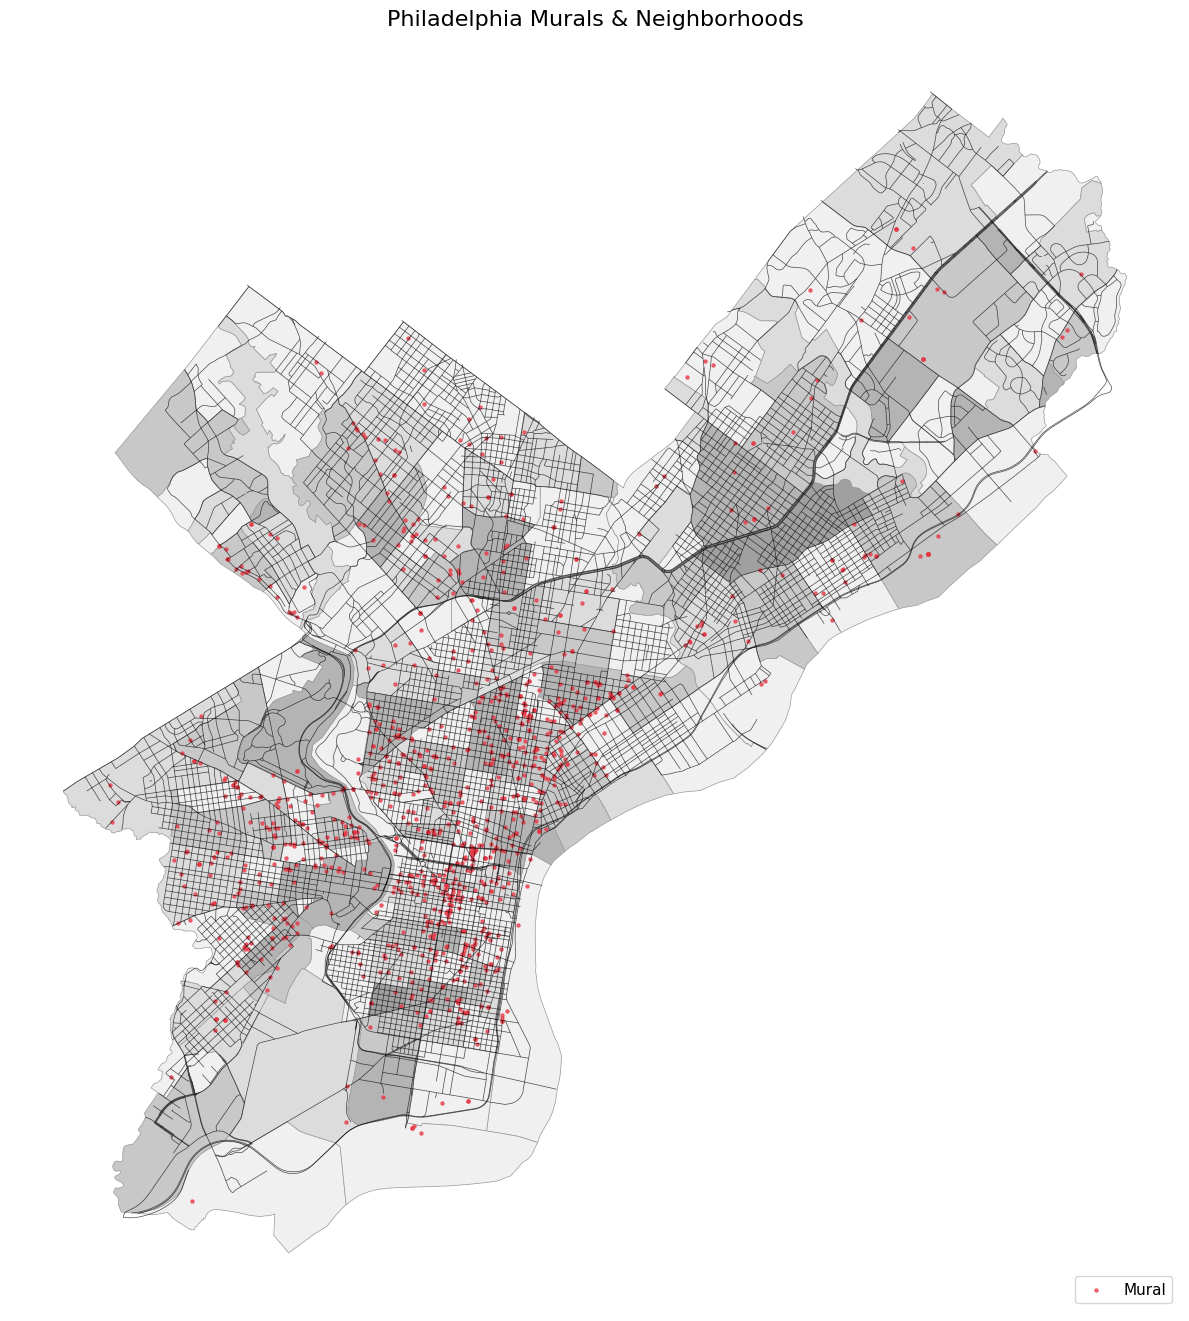

In [196]:
fig, ax = plt.subplots(figsize=(12, 14))

neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)
streets.plot(ax=ax, color='black', linewidth=0.5, alpha=0.7)
murals_gdf.plot(ax=ax, color='#e63946', markersize=5, alpha=0.7, marker='o', label='Mural')

ax.set_title('Philadelphia Murals & Neighborhoods', fontsize=16)
ax.axis('off')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/murals/map_murals.png', dpi=150, bbox_inches='tight')
plt.show()

## Green Space Datasets

Three complementary environmental-intervention layers, all from OpenDataPhilly:

| Dataset | Description |
|---|---|
| **LandCare** | Vacant parcels greened by the Pennsylvania Horticultural Society under city contract — the exact dataset used in Branas et al. (2018) |
| **PPR Properties** | Formal parks and recreation properties managed by Philadelphia Parks & Recreation |
| **PPR Program Sites** | Active community sites (recreation centres, pools, playgrounds) |

These layers are analysed in three configurations: greenspace alone (Model A), murals alone (Model B), combined features (Model C), and combined features with an interaction term to test for synergy effects (Model D).

In [197]:
# Load green space datasets
landcare_gdf  = gpd.read_file('data/greenspace/landcare.geojson')
ppr_props_gdf = gpd.read_file('data/greenspace/ppr_properties.geojson')
ppr_sites_gdf = gpd.read_file('data/greenspace/ppr_program_sites.geojson')

# Align CRS to neighborhoods (EPSG:4326)
for gdf in [landcare_gdf, ppr_props_gdf, ppr_sites_gdf]:
    gdf.to_crs(neighborhoods.crs, inplace=True)

In [198]:
for name, gdf in [('LandCare', landcare_gdf), ('PPR Properties', ppr_props_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    print(f"{name}")
    print(f"  Shape             : {gdf.shape}")
    print(f"  CRS               : {gdf.crs}")
    print(f"  Invalid geometries: {(~gdf.geometry.is_valid).sum()}")
    print(f"  Null geometries   : {gdf.geometry.isna().sum()}")
    print(f"  Columns           : {list(gdf.columns)}")
    print()

LandCare
  Shape             : (12183, 16)
  CRS               : EPSG:4326
  Invalid geometries: 0
  Null geometries   : 0
  Columns           : ['address', 'addr_range', 'zipcode', 'district', 'year', 'season', 'program', 'stabilized', 'numparcelssite', 'parcelarea', 'objectid', 'brt_id', 'globalid', 'Shape__Area', 'Shape__Length', 'geometry']

PPR Properties
  Shape             : (505, 26)
  CRS               : EPSG:4326
  Invalid geometries: 8
  Null geometries   : 0
  Columns           : ['nested', 'official_name', 'label', 'alias', 'address_911', 'zip_code', 'alias_address', 'acreage', 'property_classification', 'ppr_use', 'ppr_prog_district', 'ppr_ops_district', 'council_district', 'police_district', 'program_sites', 'comments', 'objectid', 'site_name', 'park_name', 'ppr_ranger_district', 'ppr_park_id', 'ppr_site_id', 'ppr_asset_id', 'Shape__Area', 'Shape__Length', 'geometry']

PPR Program Sites
  Shape             : (169, 11)
  CRS               : EPSG:4326
  Invalid geometries:

In [199]:
print("Before clipping:")
for name, gdf in [('LandCare', landcare_gdf), ('PPR Properties', ppr_props_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    print(f"  {name}: {len(gdf):,}")

landcare_gdf  = landcare_gdf[landcare_gdf.geometry.within(philly_boundary) |
                              landcare_gdf.geometry.intersects(philly_boundary)].reset_index(drop=True)
ppr_props_gdf = ppr_props_gdf[ppr_props_gdf.geometry.within(philly_boundary) |
                               ppr_props_gdf.geometry.intersects(philly_boundary)].reset_index(drop=True)
ppr_sites_gdf = ppr_sites_gdf[ppr_sites_gdf.geometry.within(philly_boundary) |
                               ppr_sites_gdf.geometry.intersects(philly_boundary)].reset_index(drop=True)

print("\nAfter clipping:")
for name, gdf in [('LandCare', landcare_gdf), ('PPR Properties', ppr_props_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    print(f"  {name}: {len(gdf):,}")

Before clipping:
  LandCare: 12,183
  PPR Properties: 505
  PPR Program Sites: 169

After clipping:
  LandCare: 12,183
  PPR Properties: 504
  PPR Program Sites: 169


In [200]:
# ── LandCare: quick EDA ───────────────────────────────────────────────────────

print("LandCare program types:")
print(landcare_gdf['program'].value_counts().head(15))

print("\nLandCare year distribution:")
print(landcare_gdf['year'].value_counts().sort_index().to_string())

print("\nLandCare parcel area stats (sq ft):")
pd.set_option('display.float_format', '{:.2f}'.format)
print(landcare_gdf['parcelarea'].describe().to_string())

with pd.option_context('display.max_rows', None):
    print(landcare_gdf['year'].value_counts().sort_index())

LandCare program types:
program
PLC              7201
CLC              3269
Deeply Rooted     666
LandBank          617
PHDC              430
Name: count, dtype: int64

LandCare year distribution:
year
        3012
1993       3
2000      17
2001      22
2002      62
2003     201
2004     365
2005     128
2006     304
2007     424
2008     494
2009      55
2010     233
2011     357
2012     300
2013     219
2014     281
2015     197
2016     560
2017     294
2018     340
2019     250
2020     239
2021     308
2022     954
2023     634
2024     578
2025     444

LandCare parcel area stats (sq ft):
count   12182.00
mean     1349.47
std      2101.37
min        78.00
25%       746.00
50%      1019.00
75%      1379.00
max     68081.00
year
        3012
1993       3
2000      17
2001      22
2002      62
2003     201
2004     365
2005     128
2006     304
2007     424
2008     494
2009      55
2010     233
2011     357
2012     300
2013     219
2014     281
2015     197
2016     560
2017     

In [201]:
# Inspect what the 'missing' years actually look like
print(landcare_gdf['year'].value_counts(dropna=False).head(10))
print(f"\nSample of unusual year values:")
print(landcare_gdf[landcare_gdf['year'].str.len() != 4]['year'].value_counts())

year
        3012
2022     954
NaN      908
2023     634
2024     578
2016     560
2008     494
2025     444
2007     424
2004     365
Name: count, dtype: int64

Sample of unusual year values:
year
    3012
Name: count, dtype: int64


In [202]:
# Remove LandCare records with no year — required for temporal analysis
print(f"LandCare before year filter: {len(landcare_gdf):,}")
landcare_gdf = landcare_gdf[landcare_gdf['year'].str.strip() != ''].reset_index(drop=True)
print(f"LandCare after year filter : {len(landcare_gdf):,}")
print(f"Removed                    : {12183 - len(landcare_gdf):,} records")

LandCare before year filter: 12,183
LandCare after year filter : 9,171
Removed                    : 3,012 records


In [203]:
print(landcare_gdf.nlargest(5, 'parcelarea')[['program', 'year', 'parcelarea', 'geometry']])

     program  year  parcelarea  \
7389     PLC  2024    62026.00   
899      PLC  2014    60744.00   
647      PLC  2007    54337.00   
7106     PLC  2025    47189.00   
7326     CLC   NaN    41969.00   

                                               geometry  
7389  POLYGON ((-75.1362 39.99245, -75.13708 39.9925...  
899   POLYGON ((-75.17883 39.99047, -75.17891 39.990...  
647   POLYGON ((-75.21607 39.97368, -75.2161 39.9733...  
7106  POLYGON ((-75.21414 39.95853, -75.21426 39.957...  
7326  POLYGON ((-75.18234 40.04236, -75.18262 40.042...  


In [204]:
# ── PPR Properties: quick EDA ────────────────────────────────────────────────

print("PPR property classifications:")
print(ppr_props_gdf['property_classification'].value_counts())

print("\nPPR uses:")
print(ppr_props_gdf['ppr_use'].value_counts().head(15))

print("\nPPR Program Sites — program types:")
print(ppr_sites_gdf['program_type'].value_counts())

PPR property classifications:
property_classification
PARK                     345
MANAGED_SITE              51
TRAFFIC_ISLAND_MEDIAN     28
PATHWAY                   21
OTHER                     18
WATERSHED_PARK            16
CONSERVATION              15
URBAN_AGRICULTURE          6
OPERATIONAL_INTERNAL       4
Name: count, dtype: int64

PPR uses:
ppr_use
RECREATION_SITE                   192
SQUARE_PLAZA                       77
NEIGHBORHOOD_PARK                  63
NATURE_AREA                        41
SPORTS_COMPLEX                     37
OTHER                              24
GREENWAY                           18
GARDEN_FARM                        11
HISTORIC_SITE                       8
MUSEUM_CAMPUS                       7
GOLF                                6
OLDER_ADULT_SITE                    6
EVENT_SPACE                         5
OPERATIONS                          4
ENVIRONMENTAL_EDUCATION_CENTER      3
Name: count, dtype: int64

PPR Program Sites — program types:
program_

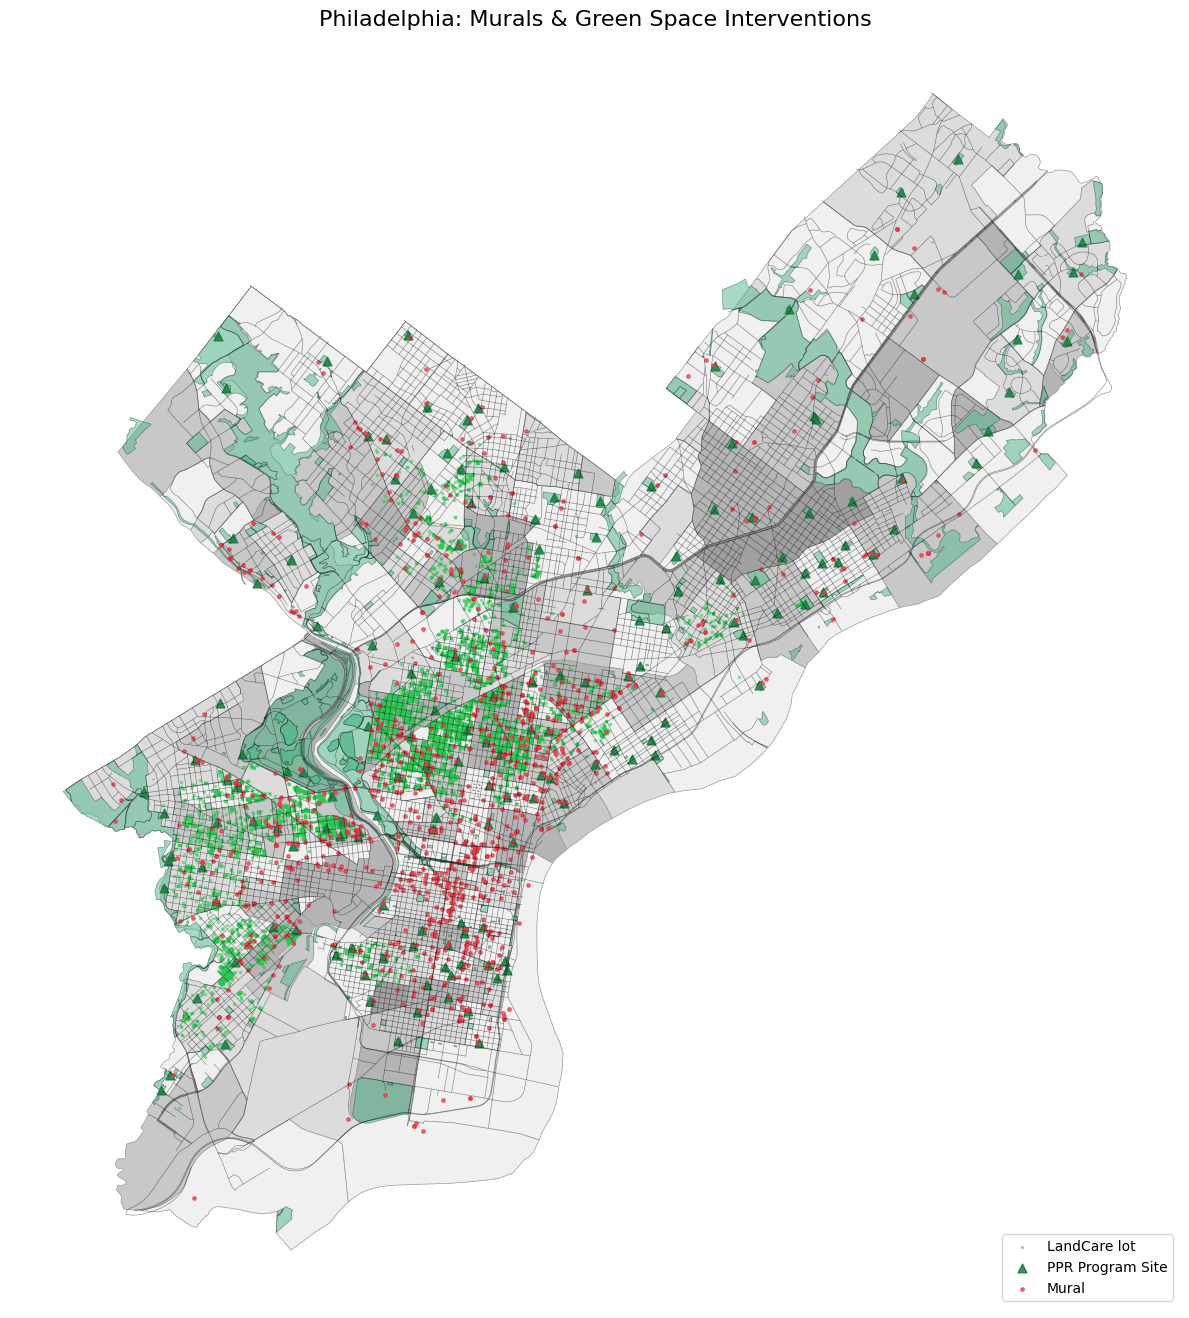

In [ ]:
# ── Combined map: murals + all green space layers ─────────────────────────────

# LandCare centroids (polygons → points for plotting)
landcare_centroids = landcare_gdf.copy()
landcare_centroids['geometry'] = landcare_gdf.geometry.centroid

fig, ax = plt.subplots(figsize=(12, 14))

# Base: neighborhoods
neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)

# Major streets
streets.plot(ax=ax, color='black', linewidth=0.4, alpha=0.5)

# LandCare greened lots (small, semi-transparent green squares)
landcare_centroids.plot(
    ax=ax, color='#2dc653', markersize=3, alpha=0.4, marker='s', label='LandCare lot'
)

# PPR Properties (park polygons — filled green)
ppr_props_gdf.plot(
    ax=ax, color='#52b788', edgecolor='#1b4332', linewidth=0.5, alpha=0.5, label='PPR Property'
)

# PPR Program Sites (triangles — active community sites)
ppr_sites_gdf.plot(
    ax=ax, color='#1b7c3e', markersize=40, alpha=0.85, marker='^', label='PPR Program Site'
)

# Murals (red dots, on top)
murals_gdf.plot(
    ax=ax, color='#e63946', markersize=6, alpha=0.7, marker='o', label='Mural'
)

ax.set_title('Philadelphia: Murals & Green Space Interventions', fontsize=16)
ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/map_all_interventions.png', dpi=150, bbox_inches='tight')
plt.show()

## Neighborhood-Level Feature Matrix

Each row = one Philadelphia neighborhood. We compute per-km² densities for each intervention type so that small and large neighborhoods are comparable.

The feature matrix will support three model variants per algorithm:

| Model | Features | Purpose |
|---|---|---|
| **Model A** | Mural density only | Baseline — isolates mural effect |
| **Model B** | Green space density only | Greenspace-only comparison |
| **Model C** | Murals + green space combined | Augmented — tests synergy |

In [206]:
# ── Project to a metric CRS for area / distance calculations ─────────────────
# EPSG:32618  =  UTM Zone 18N  (Philadelphia falls here)
CRS_METRIC = 'EPSG:32618'

nbhd_m   = neighborhoods.to_crs(CRS_METRIC).copy()
murals_m = murals_gdf.to_crs(CRS_METRIC).copy()

landcare_m   = landcare_gdf.to_crs(CRS_METRIC).copy()
ppr_props_m  = ppr_props_gdf.to_crs(CRS_METRIC).copy()
ppr_sites_m  = ppr_sites_gdf.to_crs(CRS_METRIC).copy()

# Neighborhood area in km²
nbhd_m['area_km2'] = nbhd_m.geometry.area / 1e6
print(f"Neighborhood area range: {nbhd_m['area_km2'].min():.2f} – {nbhd_m['area_km2'].max():.2f} km²")

Neighborhood area range: 0.12 – 12.00 km²


In [207]:
# ── Spatial join helper ───────────────────────────────────────────────────────

def count_per_neighborhood(points_gdf, nbhd_gdf, col_name):
    """Spatial join points → neighborhoods, return count per NAME."""
    joined = gpd.sjoin(points_gdf[['geometry']], nbhd_gdf[['NAME', 'geometry']],
                       how='left', predicate='within')
    counts = joined.groupby('NAME').size().reset_index(name=col_name)
    return counts


# ── Mural counts ──────────────────────────────────────────────────────────────
mural_counts = count_per_neighborhood(murals_m, nbhd_m, 'mural_count')

# ── LandCare counts & greened area ───────────────────────────────────────────
landcare_pts = landcare_m.copy()
landcare_pts['geometry'] = landcare_m.geometry.centroid
landcare_counts = count_per_neighborhood(landcare_pts, nbhd_m, 'landcare_count')

lc_joined = gpd.sjoin(
    landcare_m[['geometry', 'parcelarea']],
    nbhd_m[['NAME', 'geometry']],
    how='left', predicate='intersects'
)
lc_area = lc_joined.groupby('NAME')['parcelarea'].sum().reset_index(name='landcare_area_sqft')

# ── PPR Properties (polygon centroids + area) ─────────────────────────────────
ppr_pts = ppr_props_m.copy()
ppr_pts['geometry'] = ppr_props_m.geometry.centroid
ppr_prop_counts = count_per_neighborhood(ppr_pts, nbhd_m, 'ppr_property_count')

ppr_joined = gpd.sjoin(
    ppr_props_m[['geometry']],
    nbhd_m[['NAME', 'geometry']],
    how='left', predicate='intersects'
)
ppr_joined['ppr_area_km2'] = ppr_props_m.loc[ppr_joined.index, 'geometry'].area / 1e6
ppr_area = ppr_joined.groupby('NAME')['ppr_area_km2'].sum().reset_index()

# ── PPR Program Sites (point count) ──────────────────────────────────────────
ppr_site_counts = count_per_neighborhood(ppr_sites_m, nbhd_m, 'ppr_site_count')

print("Sample mural counts (top 5):")
print(mural_counts.sort_values('mural_count', ascending=False).head(5))
print("\nSample LandCare counts (top 5):")
print(landcare_counts.sort_values('landcare_count', ascending=False).head(5))

Sample mural counts (top 5):
                 NAME  mural_count
111   WEST_KENSINGTON           41
50          HARTRANFT           35
108  UPPER_KENSINGTON           33
60       LOGAN_SQUARE           30
8          CALLOWHILL           29

Sample LandCare counts (top 5):
                  NAME  landcare_count
58  STRAWBERRY_MANSION            1014
57             STANTON             943
32           HARTRANFT             736
46       NORTH_CENTRAL             722
62     WEST_KENSINGTON             553


In [208]:
# ── Build the unified neighborhood feature matrix ─────────────────────────────

feat = nbhd_m[['NAME', 'area_km2']].copy()

for df in [mural_counts, landcare_counts, lc_area,
           ppr_prop_counts, ppr_area, ppr_site_counts]:
    feat = feat.merge(df, on='NAME', how='left')

feat = feat.fillna(0)

# Per-km² density columns
feat['mural_density']    = feat['mural_count']       / feat['area_km2']
feat['landcare_density'] = feat['landcare_count']     / feat['area_km2']
feat['ppr_prop_density'] = feat['ppr_property_count'] / feat['area_km2']
feat['ppr_site_density'] = feat['ppr_site_count']     / feat['area_km2']

# Composite green-space score (standardise each component, then sum)
from sklearn.preprocessing import StandardScaler

gs_cols = ['landcare_density', 'ppr_prop_density', 'ppr_site_density']
scaler  = StandardScaler()
feat['greenspace_score'] = scaler.fit_transform(feat[gs_cols]).sum(axis=1)

# Combined score = standardised mural density + green-space score
feat['combined_score'] = (
    StandardScaler().fit_transform(feat[['mural_density']]).ravel()
    + feat['greenspace_score']
)

print(f"Feature matrix shape: {feat.shape}")
print(f"Columns: {list(feat.columns)}")
print()
print(feat[['NAME', 'area_km2', 'mural_density', 'landcare_density',
            'greenspace_score', 'combined_score']]
      .sort_values('mural_density', ascending=False).head(10))

Feature matrix shape: (159, 14)
Columns: ['NAME', 'area_km2', 'mural_count', 'landcare_count', 'landcare_area_sqft', 'ppr_property_count', 'ppr_area_km2', 'ppr_site_count', 'mural_density', 'landcare_density', 'ppr_prop_density', 'ppr_site_density', 'greenspace_score', 'combined_score']

                  NAME  area_km2  mural_density  landcare_density  \
139         CALLOWHILL      0.54          53.54              0.00   
104        BELLA_VISTA      0.39          43.08              0.00   
75            FAIRHILL      0.70          35.84             64.51   
93         CENTER_CITY      0.38          34.17              0.00   
94   WASHINGTON_SQUARE      0.85          34.15              0.00   
108          GREENWICH      0.18          32.83             16.42   
92           CHINATOWN      0.13          23.76              0.00   
85     WEST_KENSINGTON      1.81          22.60            304.84   
97       SPRING_GARDEN      0.63          22.26              0.00   
141        EAST_POPLA

In [209]:
# ── Save feature matrix (crime data will be merged in later) ──────────────────
feat.to_csv('data/neighborhood_features.csv', index=False)
print("Saved → data/neighborhood_features.csv")
print(f"  Rows: {len(feat)}  |  Cols: {feat.shape[1]}")
print()
print("Density summary:")
print(feat[['mural_density', 'landcare_density', 'ppr_prop_density',
            'ppr_site_density', 'greenspace_score']].describe().round(3))

Saved → data/neighborhood_features.csv
  Rows: 159  |  Cols: 14

Density summary:
       mural_density  landcare_density  ppr_prop_density  ppr_site_density  \
count         159.00            159.00            159.00            159.00   
mean            6.32             42.09              2.18              0.66   
std             8.89            104.77              2.60              0.93   
min             0.00              0.00              0.00              0.00   
25%             0.24              0.00              0.62              0.00   
50%             2.91              0.00              1.38              0.34   
75%             9.13             25.39              2.73              0.95   
max            53.54            802.31             13.31              5.47   

       greenspace_score  
count            159.00  
mean               0.00  
std                2.05  
min               -1.95  
25%               -1.49  
50%               -0.62  
75%                0.79  
max    

## Crime Data

Philadelphia Police incident-level crime data from OpenDataPhilly (`incidents_part1_part2`).

- **Source**: Philadelphia Police Department via Carto/OpenDataPhilly
- **Period**: 2018–2024 (7 years, 1,048,762 incidents)
- **Columns**: `dc_dist`, `psa`, `dispatch_date`, `hour`, `ucr_general`, `text_general_code`, `point_x`, `point_y`

Crime incidents are spatially joined to neighborhoods then aggregated into three response variables:

| Variable | Definition | Theoretical link |
|---|---|---|
| `crime_rate_total` | All incidents / km² | Overall safety signal |
| `crime_rate_property` | Theft + Vandalism + Burglary / km² | CPTED: murals should reduce this most |
| `crime_rate_violent` | Assault + Robbery + Weapons / km² | Less likely to respond to environmental cues |

In [210]:
# ── Load crime CSV ────────────────────────────────────────────────────────────
crime_df = pd.read_csv(
    'data/crime/philly_crime_2018_2024.csv',
    low_memory=False,
    parse_dates=['dispatch_date']
)

print(f"Shape: {crime_df.shape}")
print(f"Date range: {crime_df['dispatch_date'].min().date()} → {crime_df['dispatch_date'].max().date()}")
print(f"\nNulls:\n{crime_df.isnull().sum()}")
print(f"\nCrime types:\n{crime_df['text_general_code'].value_counts().head(15)}")

Shape: (1048762, 11)
Date range: 2018-01-01 → 2024-12-31

Nulls:
dc_dist                  0
psa                    461
dispatch_date            0
dispatch_time            0
hour                 98425
dc_key                   0
location_block          76
ucr_general              0
text_general_code        0
point_x                  0
point_y                  0
dtype: int64

Crime types:
text_general_code
Thefts                            200733
Other Assaults                    170686
All Other Offenses                121706
Vandalism/Criminal Mischief       102008
Theft from Vehicle                 89600
Fraud                              62070
Motor Vehicle Theft                60729
Narcotic / Drug Law Violations     38399
Aggravated Assault No Firearm      36730
Burglary Residential               27871
Aggravated Assault Firearm         21764
Weapon Violations                  20645
Robbery No Firearm                 19788
Robbery Firearm                    15660
Burglary Non-Reside

In [211]:
# ── Classify crime types ──────────────────────────────────────────────────────

PROPERTY_CRIMES = {
    'Thefts', 'Theft from Vehicle', 'Motor Vehicle Theft',
    'Vandalism/Criminal Mischief', 'Burglary Residential',
    'Burglary Non-Residential', 'Fraud', 'Receiving Stolen Property',
    'Arson',
}

VIOLENT_CRIMES = {
    'Aggravated Assault No Firearm', 'Aggravated Assault Firearm',
    'Robbery No Firearm', 'Robbery Firearm',
    'Weapon Violations', 'Homicide - Criminal', 'Rape', 'Other Sex Offenses',
}

crime_df['is_property'] = crime_df['text_general_code'].isin(PROPERTY_CRIMES)
crime_df['is_violent']  = crime_df['text_general_code'].isin(VIOLENT_CRIMES)

print(f"Property crimes: {crime_df['is_property'].sum():,}  ({crime_df['is_property'].mean()*100:.1f}%)")
print(f"Violent crimes : {crime_df['is_violent'].sum():,}  ({crime_df['is_violent'].mean()*100:.1f}%)")
print(f"Other          : {(~crime_df['is_property'] & ~crime_df['is_violent']).sum():,}")

Property crimes: 564,324  (53.8%)
Violent crimes : 122,791  (11.7%)
Other          : 361,647


In [212]:
# Convert crime DataFrame to GeoDataFrame (WGS84 -> metric CRS)

crime_gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df['point_x'], crime_df['point_y']),
    crs='EPSG:4326'
).to_crs(CRS_METRIC)

print(f'Crime GeoDataFrame: {crime_gdf.shape}')


Crime GeoDataFrame: (1048762, 14)


In [213]:
# Spatial join: crimes -> neighborhoods

crime_joined = gpd.sjoin(
    crime_gdf[['geometry', 'is_property', 'is_violent']],
    nbhd_m[['NAME', 'geometry']],
    how='left',
    predicate='within'
)

crime_agg = crime_joined.groupby('NAME').agg(
    crime_total    = ('is_property', 'count'),
    crime_property = ('is_property', 'sum'),
    crime_violent  = ('is_violent',  'sum'),
).reset_index()

print(f'Neighborhoods with crime data: {len(crime_agg)}')
print(crime_agg.sort_values('crime_total', ascending=False).head(10))


Neighborhoods with crime data: 159
                 NAME  crime_total  crime_property  crime_violent
136  UPPER_KENSINGTON        31779            7734           5090
22        COBBS_CREEK        27457           11426           4228
61         HADDINGTON        26104            9161           3433
117          RICHMOND        21896           10454           2621
45          FRANKFORD        21684           10017           3438
100             OLNEY        21034           10406           3133
102     OXFORD_CIRCLE        20691           12545           2382
73              LOGAN        20015            8868           3032
62         HARROWGATE        19769            8796           2914
118       RITTENHOUSE        19701           14282           1179


In [214]:
# Merge crime counts into feature matrix and compute per-km2 rates

feat = feat.merge(crime_agg, on='NAME', how='left').fillna(0)

feat['crime_rate_total']    = feat['crime_total']    / feat['area_km2']
feat['crime_rate_property'] = feat['crime_property'] / feat['area_km2']
feat['crime_rate_violent']  = feat['crime_violent']  / feat['area_km2']

print(f'Final feature matrix: {feat.shape}')
print(feat[['NAME', 'mural_density', 'greenspace_score',
            'crime_rate_total', 'crime_rate_property', 'crime_rate_violent']]
      .sort_values('crime_rate_total', ascending=False).head(10))


Final feature matrix: (159, 20)
                  NAME  mural_density  greenspace_score  crime_rate_total  \
93         CENTER_CITY          34.17             -0.94          21979.41   
94   WASHINGTON_SQUARE          34.15              1.58          20724.72   
76    UPPER_KENSINGTON          15.61              0.77          15034.70   
99         RITTENHOUSE          16.21             -1.38          14514.74   
78             STANTON           8.51              7.89          13421.50   
135         HADDINGTON           2.42              0.31          12611.18   
92           CHINATOWN          23.76             -1.95          10644.40   
108          GREENWICH          32.83              8.30          10424.44   
130    HAVERFORD_NORTH           7.56              1.23          10374.93   
81       NORTH_CENTRAL          15.17              5.00          10104.80   

     crime_rate_property  crime_rate_violent  
93              12821.76             1860.97  
94              13221.00  

In [215]:
# Save final feature matrix

feat.to_csv('data/neighborhood_features.csv', index=False)

print('Saved data/neighborhood_features.csv')
print(f'Shape: {feat.shape}')
print()
print('Response variable summary:')
print(feat[['crime_rate_total', 'crime_rate_property', 'crime_rate_violent']].describe().round(1))


Saved data/neighborhood_features.csv
Shape: (159, 20)

Response variable summary:
       crime_rate_total  crime_rate_property  crime_rate_violent
count            159.00               159.00              159.00
mean            4337.90              2354.70              488.00
std             3702.80              2029.50              470.30
min               19.10                12.10                0.50
25%             1275.80               837.60               78.30
50%             3971.80              2228.30              372.90
75%             6246.00              3254.50              774.70
max            21979.40             13221.00             2408.10


## Exploratory Data Analysis

With the full feature matrix assembled, we explore:
1. Distributions of crime rates and intervention densities
2. Correlations between mural density and crime rates
3. Whether murals + green space together show stronger correlation than either alone
4. Choropleth maps to visualise spatial patterns


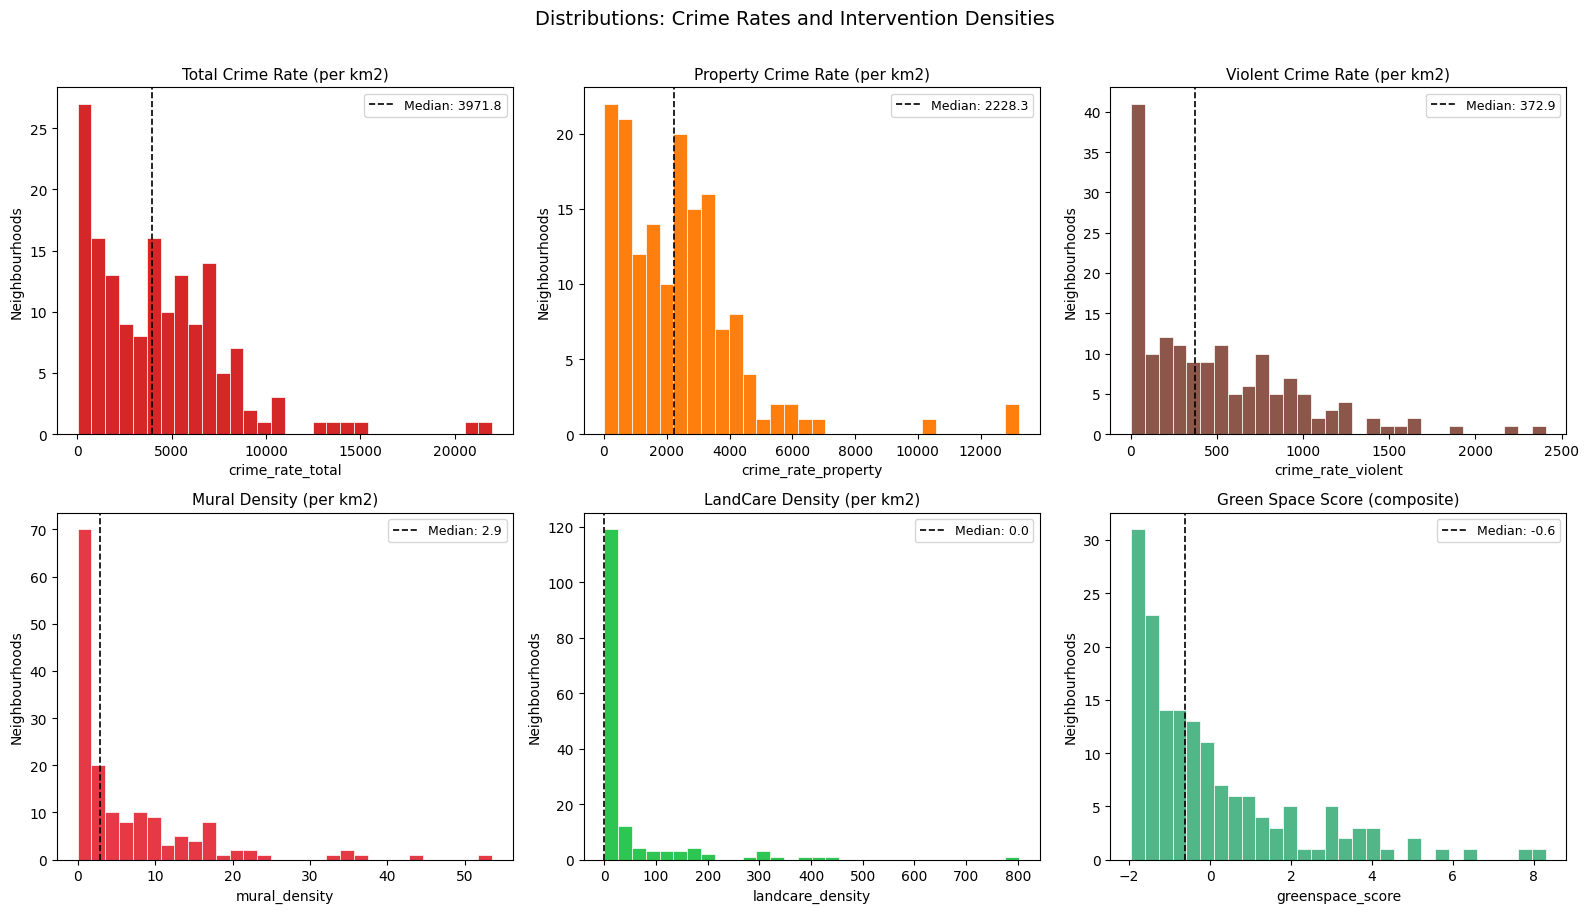

In [216]:
# Distribution plots: crime rates and intervention densities

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

pairs = [
    ('crime_rate_total',    'Total Crime Rate (per km2)',    '#d62728'),
    ('crime_rate_property', 'Property Crime Rate (per km2)', '#ff7f0e'),
    ('crime_rate_violent',  'Violent Crime Rate (per km2)',  '#8c564b'),
    ('mural_density',       'Mural Density (per km2)',       '#e63946'),
    ('landcare_density',    'LandCare Density (per km2)',    '#2dc653'),
    ('greenspace_score',    'Green Space Score (composite)', '#52b788'),
]

for ax, (col, title, colour) in zip(axes.flat, pairs):
    data = feat[col]
    ax.hist(data, bins=30, color=colour, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.1f}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Neighbourhoods')
    ax.legend(fontsize=9)

plt.suptitle('Distributions: Crime Rates and Intervention Densities', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outputs/distributions.png', dpi=150, bbox_inches='tight')
plt.show()


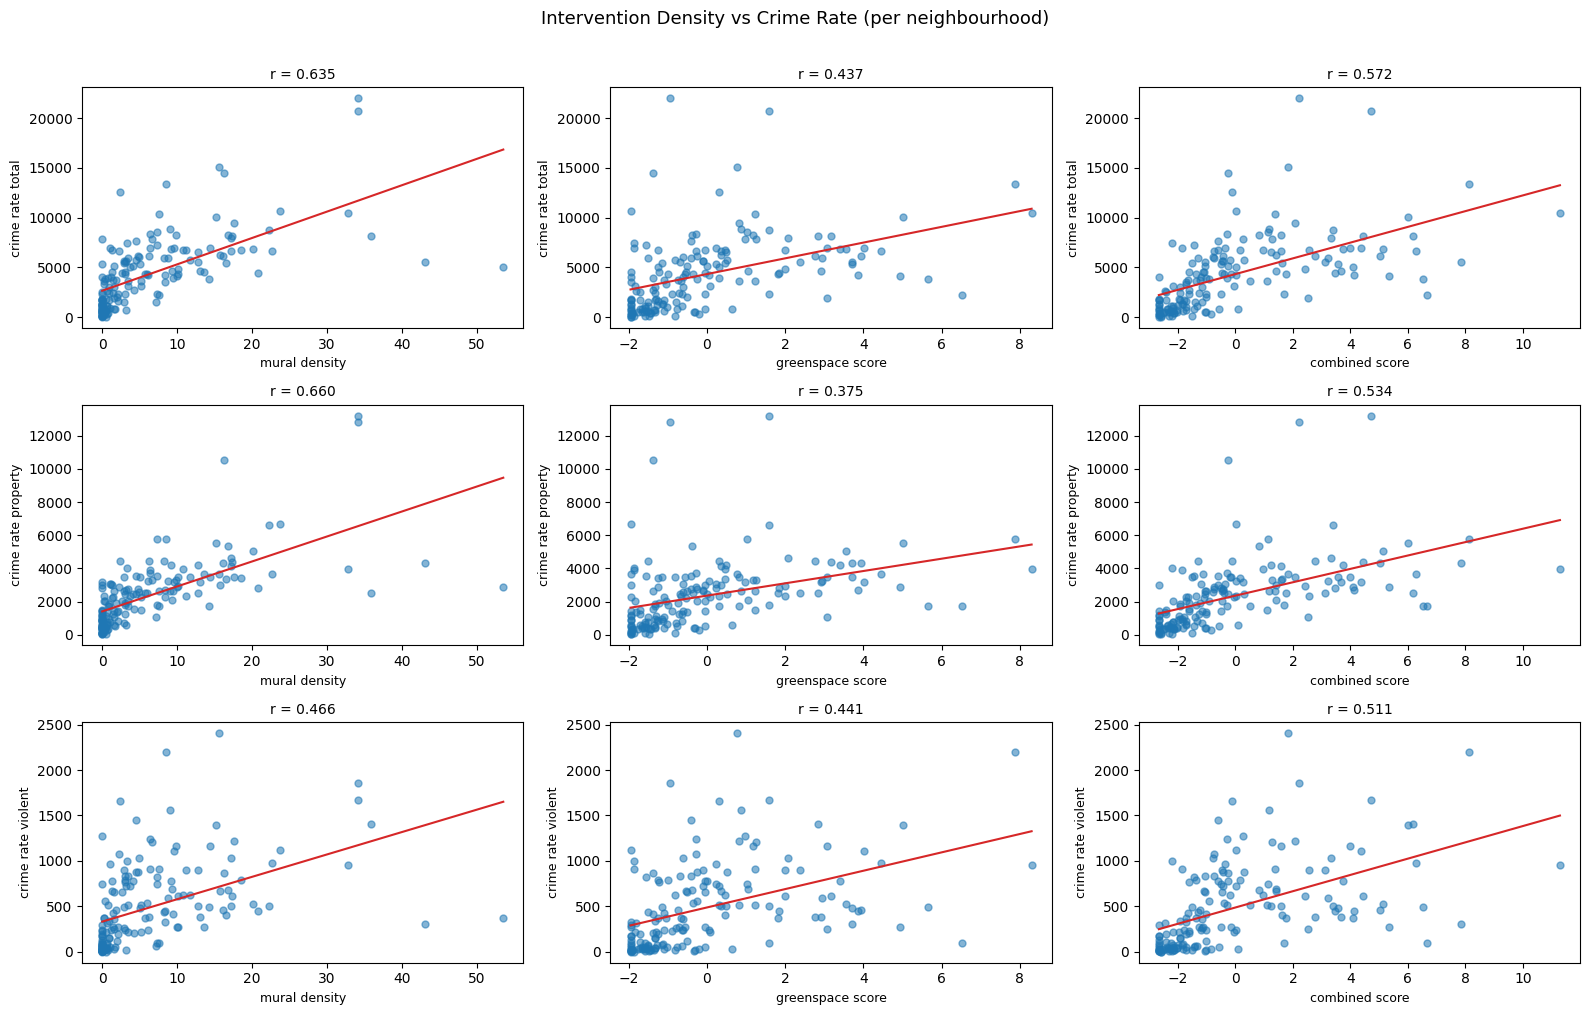

In [217]:
# Scatter matrix: intervention density vs crime rates

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

x_vars = ['mural_density', 'greenspace_score', 'combined_score']
y_vars = ['crime_rate_total', 'crime_rate_property', 'crime_rate_violent']

for row_i, y_col in enumerate(y_vars):
    for col_i, x_col in enumerate(x_vars):
        ax = axes[row_i][col_i]
        ax.scatter(feat[x_col], feat[y_col], alpha=0.55, s=25, color='#1f77b4')
        mask = feat[x_col].notna() & feat[y_col].notna()
        m, b = np.polyfit(feat.loc[mask, x_col], feat.loc[mask, y_col], 1)
        x_line = np.linspace(feat[x_col].min(), feat[x_col].max(), 100)
        ax.plot(x_line, m * x_line + b, color='#d62728', linewidth=1.5)
        corr = feat[[x_col, y_col]].corr().iloc[0, 1]
        ax.set_title(f'r = {corr:.3f}', fontsize=10)
        ax.set_xlabel(x_col.replace('_', ' '), fontsize=9)
        ax.set_ylabel(y_col.replace('_', ' '), fontsize=9)

plt.suptitle('Intervention Density vs Crime Rate (per neighbourhood)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


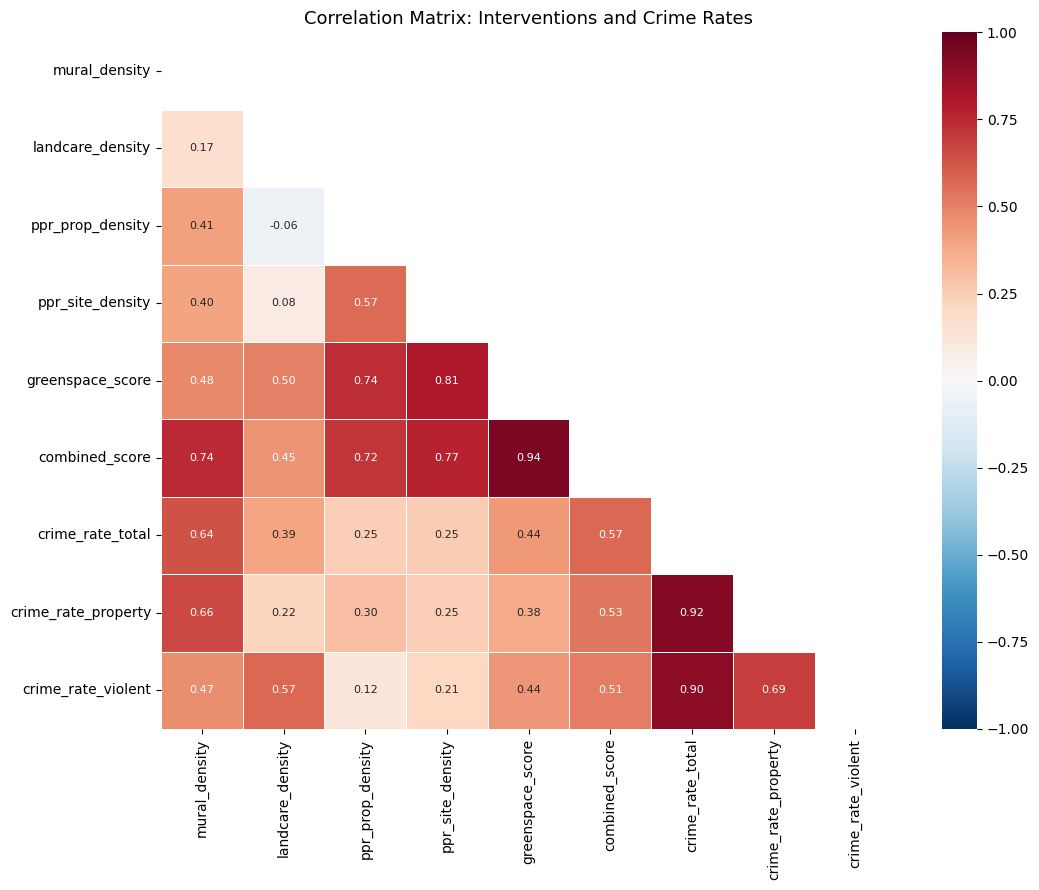

In [218]:
# Correlation heatmap: all key features

cols_for_corr = [
    'mural_density', 'landcare_density', 'ppr_prop_density', 'ppr_site_density',
    'greenspace_score', 'combined_score',
    'crime_rate_total', 'crime_rate_property', 'crime_rate_violent',
]

corr_matrix = feat[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix: Interventions and Crime Rates', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


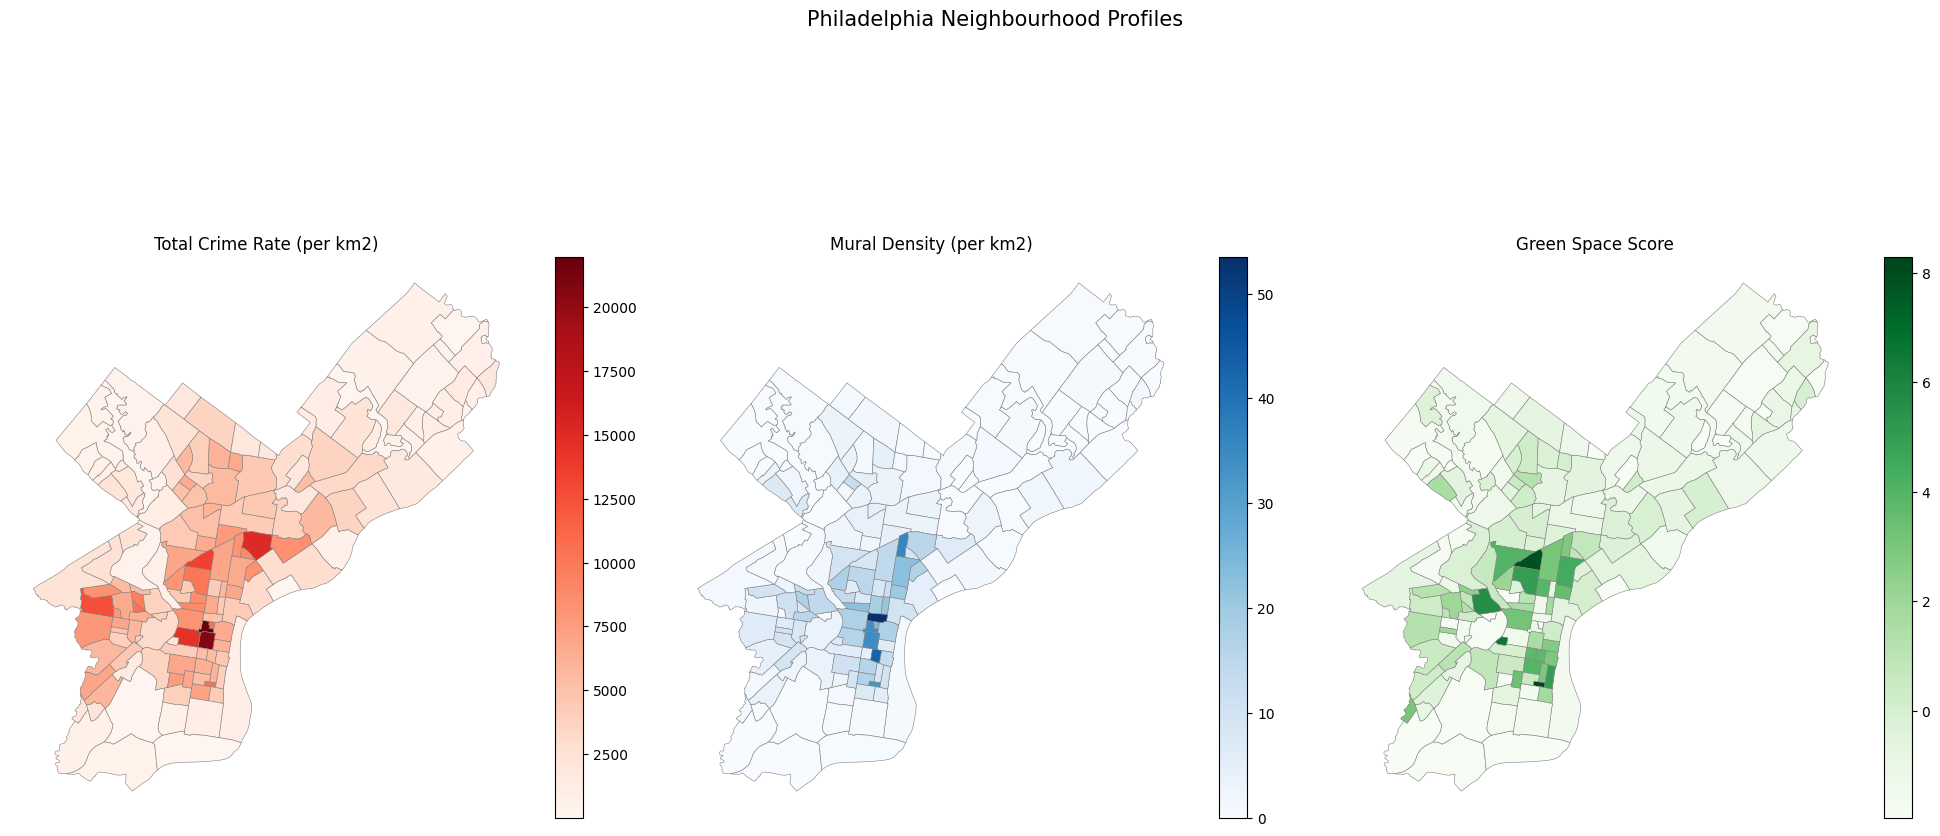

In [219]:
# Choropleth maps: crime rate, mural density, green space score

nbhd_plot = nbhd_m.merge(
    feat[['NAME', 'crime_rate_total', 'mural_density', 'greenspace_score']],
    on='NAME', how='left'
).to_crs('EPSG:4326')

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for ax, col, cmap, title in [
    (axes[0], 'crime_rate_total',  'Reds',   'Total Crime Rate (per km2)'),
    (axes[1], 'mural_density',     'Blues',  'Mural Density (per km2)'),
    (axes[2], 'greenspace_score',  'Greens', 'Green Space Score'),
]:
    nbhd_plot.plot(
        column=col, cmap=cmap, linewidth=0.4, edgecolor='grey',
        legend=True, ax=ax, legend_kwds={'shrink': 0.6}
    )
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Philadelphia Neighbourhood Profiles', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('outputs/choropleths.png', dpi=150, bbox_inches='tight')
plt.show()


## Machine Learning Models

Four algorithms address the four research questions under the **dual-intervention design**: every model is trained three times — **Model A** (mural density only), **Model B** (greenspace score only), **Model C** (combined) — so the performance delta C − A quantifies synergy between murals and greening.

### RQ1 — OLS Linear Regression

Do mural density and greenspace score predict neighbourhood crime rate per km²?  
Controls: area-normalised crime rates used as targets.  
Metrics: cross-validated R² and RMSE (5-fold CV).

RQ1 — OLS Regression Results (5-fold CV)

  Target               Model  R2_CV  RMSE_CV  Coef_mural  Coef_green
   Total     A (Murals only)  -0.86  3059.60      264.64         NaN
   Total B (Greenspace only)  -1.62  3424.40         NaN      789.78
   Total        C (Combined)  -0.73  3077.40      230.37      307.82
Property     A (Murals only)  -0.70  1615.40      150.73         NaN
Property B (Greenspace only)  -1.69  1879.30         NaN      371.54
Property        C (Combined)  -0.70  1648.00      142.58       73.25
 Violent     A (Murals only)  -1.17   444.30       24.63         NaN
 Violent B (Greenspace only)  -1.36   453.00         NaN      101.03
 Violent        C (Combined)  -1.05   442.70       17.44       64.54


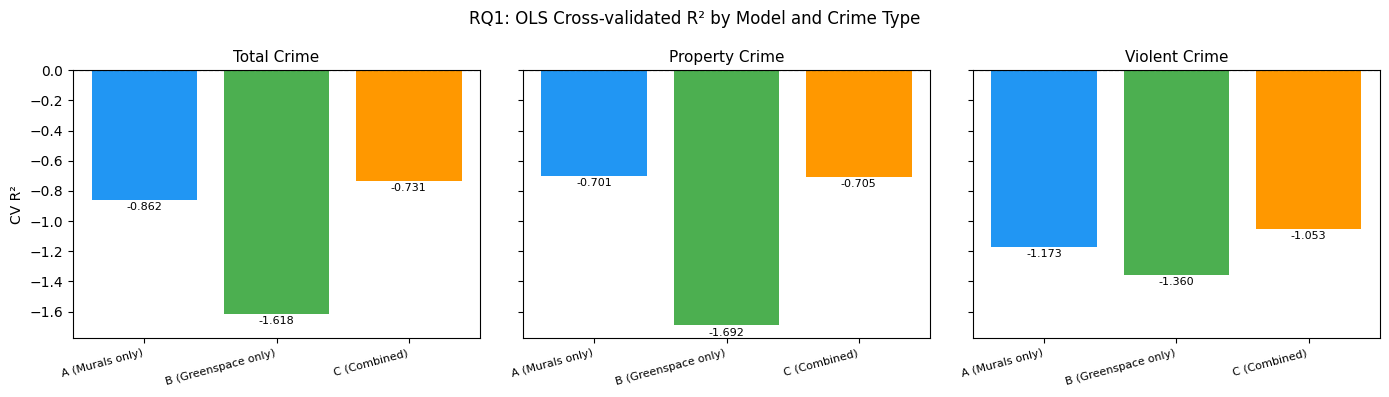


Note: negative R² indicates these single predictors perform worse than the mean
baseline, consistent with selection bias — murals are placed in already-high-crime areas.


In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv('data/neighborhood_features.csv')

model_configs = {
    'A (Murals only)':     ['mural_density'],
    'B (Greenspace only)': ['greenspace_score'],
    'C (Combined)':        ['mural_density', 'greenspace_score'],
}
targets = {
    'Total':    'crime_rate_total',
    'Property': 'crime_rate_property',
    'Violent':  'crime_rate_violent',
}

rq1_rows = []
for tname, tcol in targets.items():
    y = df[tcol].values
    for mname, feats in model_configs.items():
        X = df[feats].values
        lr = LinearRegression()
        r2_cv   = cross_val_score(lr, X, y, cv=5, scoring='r2').mean()
        rmse_cv = np.sqrt(-cross_val_score(lr, X, y, cv=5,
                                           scoring='neg_mean_squared_error')).mean()
        lr.fit(X, y)
        rq1_rows.append({
            'Target':     tname,
            'Model':      mname,
            'R2_CV':      round(r2_cv,   3),
            'RMSE_CV':    round(rmse_cv, 1),
            'Coef_mural': round(lr.coef_[feats.index('mural_density')],    3)
                          if 'mural_density'   in feats else np.nan,
            'Coef_green': round(lr.coef_[feats.index('greenspace_score')], 3)
                          if 'greenspace_score' in feats else np.nan,
        })

rq1_df = pd.DataFrame(rq1_rows)
print('RQ1 — OLS Regression Results (5-fold CV)\n')
print(rq1_df.to_string(index=False))

# Bar chart: CV R² by model and crime target
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colours = ['#2196F3', '#4CAF50', '#FF9800']
for ax, (tname, _) in zip(axes, targets.items()):
    sub  = rq1_df[rq1_df['Target'] == tname]
    bars = ax.bar(sub['Model'], sub['R2_CV'], color=colours)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{tname} Crime', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('CV R²')
    ax.set_xticklabels(sub['Model'], rotation=15, ha='right', fontsize=8)
    for bar, val in zip(bars, sub['R2_CV']):
        offset = 0.02 if val >= 0 else -0.08
        ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('RQ1: OLS Cross-validated R² by Model and Crime Type', fontsize=12)
plt.tight_layout()
plt.savefig('figures/rq1_ols_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: negative R² indicates these single predictors perform worse than the mean'
      '\nbaseline, consistent with selection bias — murals are placed in already-high-crime areas.')


### RQ2 — Random Forest Classifier

Does mural presence predict **property** crime differently from **violent** crime?  
Binary labels: high crime = above-median crime rate per km².  
Metrics: weighted F1 and Cohen’s Kappa (5-fold stratified CV).

RQ2 — Random Forest Classification Results (5-fold Stratified CV)

Crime Type               Model  F1 (weighted)  Cohen's Kappa
  Property     A (Murals only)           0.79           0.58
  Property B (Greenspace only)           0.64           0.28
  Property        C (Combined)           0.81           0.61
   Violent     A (Murals only)           0.70           0.40
   Violent B (Greenspace only)           0.67           0.33
   Violent        C (Combined)           0.77           0.54


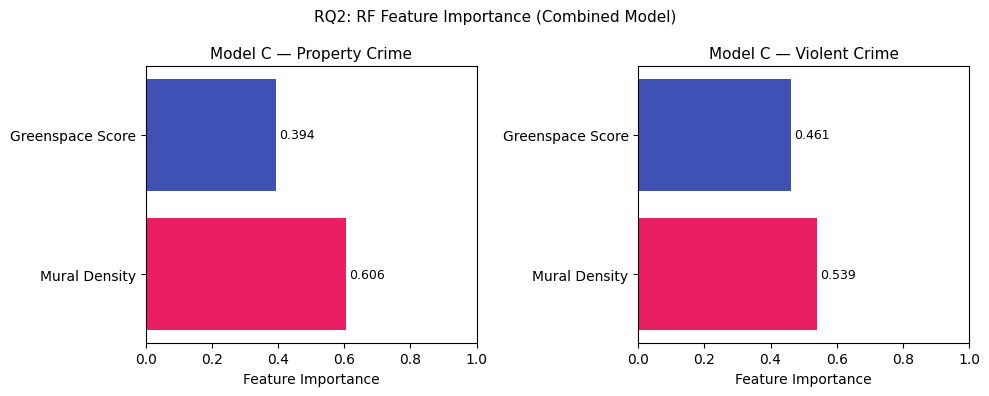

In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, cohen_kappa_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold

df = pd.read_csv('data/neighborhood_features.csv')
df['label_property'] = (df['crime_rate_property'] > df['crime_rate_property'].median()).astype(int)
df['label_violent']  = (df['crime_rate_violent']  > df['crime_rate_violent'].median()).astype(int)

model_configs = {
    'A (Murals only)':     ['mural_density'],
    'B (Greenspace only)': ['greenspace_score'],
    'C (Combined)':        ['mural_density', 'greenspace_score'],
}
crime_labels = {'Property': 'label_property', 'Violent': 'label_violent'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rq2_rows = []
fi_data  = {}   # feature importances for combined model

for ctype, lcol in crime_labels.items():
    y = df[lcol].values
    for mname, feats in model_configs.items():
        X  = df[feats].values
        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        yp = cross_val_predict(rf, X, y, cv=cv)
        rf.fit(X, y)
        rq2_rows.append({
            'Crime Type':     ctype,
            'Model':          mname,
            'F1 (weighted)':  round(f1_score(y, yp, average='weighted'), 3),
            "Cohen's Kappa":  round(cohen_kappa_score(y, yp), 3),
        })
        if mname == 'C (Combined)':
            fi_data[ctype] = dict(zip(feats, rf.feature_importances_))

rq2_df = pd.DataFrame(rq2_rows)
print('RQ2 — Random Forest Classification Results (5-fold Stratified CV)\n')
print(rq2_df.to_string(index=False))

# Feature importance bars for Model C
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
feat_labels = ['Mural Density', 'Greenspace Score']
colours     = ['#E91E63', '#3F51B5']
for ax, (ctype, fi) in zip(axes, fi_data.items()):
    vals = list(fi.values())
    bars = ax.barh(feat_labels, vals, color=colours)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Model C — {ctype} Crime', fontsize=11)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=9)

fig.suptitle('RQ2: RF Feature Importance (Combined Model)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/rq2_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### RQ3 — Spatial Analysis: Moran’s I and Spatial Lag Regression

Is the mural effect local, or do adjacent neighbourhoods also benefit?  
1. **Moran’s I** — tests spatial autocorrelation of crime rates (permutation-based p-value).  
2. **Spatial Lag Regression** (`spreg.ML_Lag`) — accounts for neighbourhood spillovers via a spatially-lagged dependent variable (ρ).  
Weights: Queen contiguity, row-standardised.

('WARNING: ', 126, ' is an island (no neighbors)')
('WARNING: ', 148, ' is an island (no neighbors)')
Moran's I Results

Crime Type  Moran's I  p-value Significant
     Total       0.54     0.00         Yes
  Property       0.54     0.00         Yes
   Violent       0.57     0.00         Yes


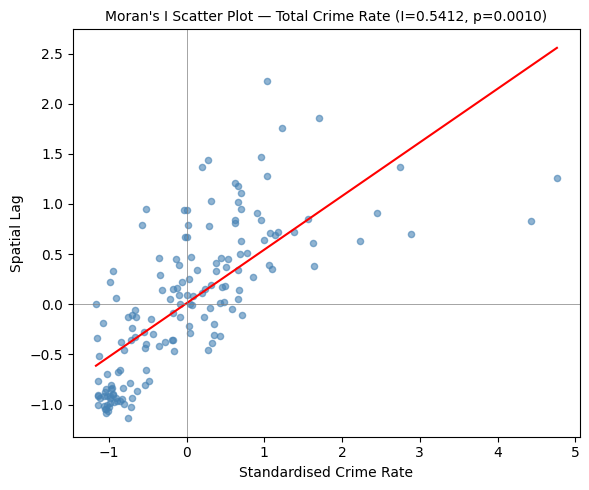

ML_Lag
ML_Lag
ML_Lag

RQ3 — Spatial Lag Regression Summary

              Model  Rho  Pseudo R2   Log-LL
    A (Murals only) 0.53       0.57 -1470.77
B (Greenspace only) 0.65       0.52 -1484.37
       C (Combined) 0.51       0.57 -1470.07


In [222]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal
import esda
import spreg
import warnings
warnings.filterwarnings('ignore')

df     = pd.read_csv('data/neighborhood_features.csv')
nb_gdf = gpd.read_file('data/maps/neighborhoods.geojson')
ndf    = nb_gdf.merge(df, on='NAME', how='inner').to_crs('EPSG:32618')

# Queen contiguity weights (row-standardised)
w = libpysal.weights.Queen.from_dataframe(ndf, use_index=False)
w.transform = 'r'

# ── Moran's I for each crime rate ─────────────────────────────────────────────
crime_cols = [
    ('crime_rate_total',    'Total'),
    ('crime_rate_property', 'Property'),
    ('crime_rate_violent',  'Violent'),
]
moran_rows = []
for col, name in crime_cols:
    mi = esda.Moran(ndf[col].values, w)
    moran_rows.append({
        'Crime Type': name,
        "Moran's I":  round(mi.I,     4),
        'p-value':    round(mi.p_sim, 4),
        'Significant': 'Yes' if mi.p_sim < 0.05 else 'No',
    })

moran_df = pd.DataFrame(moran_rows)
print("Moran's I Results\n")
print(moran_df.to_string(index=False))

# Moran scatter plot for total crime rate (manual)
mi_total = esda.Moran(ndf['crime_rate_total'].values, w)
z = (ndf['crime_rate_total'].values - ndf['crime_rate_total'].mean()) / ndf['crime_rate_total'].std()
wz = libpysal.weights.lag_spatial(w, z)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(z, wz, alpha=0.6, s=20, color='steelblue')
fit = np.polyfit(z, wz, 1)
ax.plot(np.sort(z), np.polyval(fit, np.sort(z)), color='red', linewidth=1.5)
ax.axhline(0, color='grey', linewidth=0.5); ax.axvline(0, color='grey', linewidth=0.5)
ax.set_title(f"Moran's I Scatter Plot — Total Crime Rate (I={mi_total.I:.4f}, p={mi_total.p_sim:.4f})", fontsize=10)
ax.set_xlabel('Standardised Crime Rate')
ax.set_ylabel('Spatial Lag')
plt.tight_layout()
plt.savefig('figures/rq3_moran_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Spatial Lag Regression (Model A / B / C) ──────────────────────────────────
model_configs = {
    'A (Murals only)':     ['mural_density'],
    'B (Greenspace only)': ['greenspace_score'],
    'C (Combined)':        ['mural_density', 'greenspace_score'],
}
y = ndf[['crime_rate_total']].values
sl_rows = []
for mname, feats in model_configs.items():
    X  = ndf[feats].values
    sl = spreg.ML_Lag(y, X, w=w,
                      name_y='crime_rate_total', name_x=feats)
    sl_rows.append({
        'Model':      mname,
        'Rho':        round(sl.rho,   4),
        'Pseudo R2':  round(sl.pr2,   4),
        'Log-LL':     round(sl.logll, 2),
    })

sl_df = pd.DataFrame(sl_rows)
print("\nRQ3 — Spatial Lag Regression Summary\n")
print(sl_df.to_string(index=False))


### RQ4 — K-Means Clustering

Do neighbourhoods cluster into distinct profiles by mural + crime composition, revealing selection bias?  
Features: `mural_density`, `greenspace_score`, `crime_rate_total` (all z-scored).  
Optimal K chosen by silhouette score; cluster profiles examined for CPTED selection-bias patterns.

Optimal K (max silhouette): 2  (score=0.521)


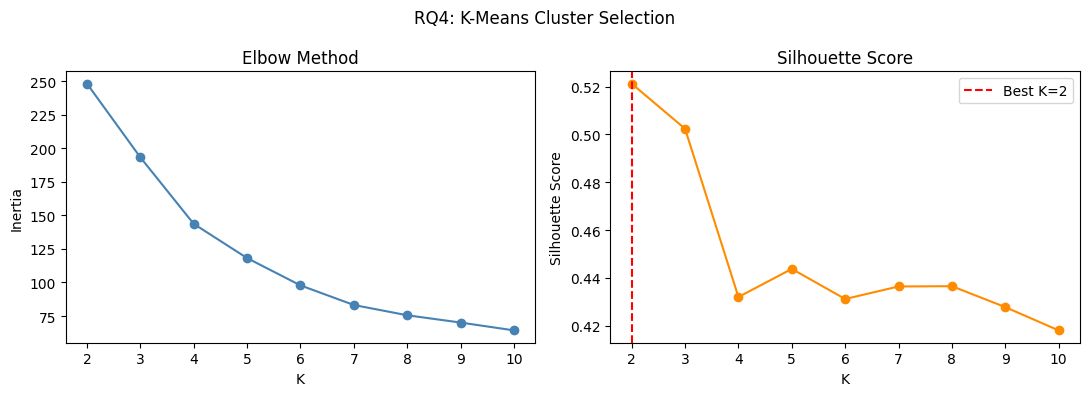


Cluster Profiles (mean values):

         mural_density  greenspace_score  crime_rate_total  crime_rate_property  crime_rate_violent
cluster                                                                                            
0                16.49              2.23           8081.06              4309.59              878.28
1                 2.18             -0.91           2814.09              1558.87              329.10


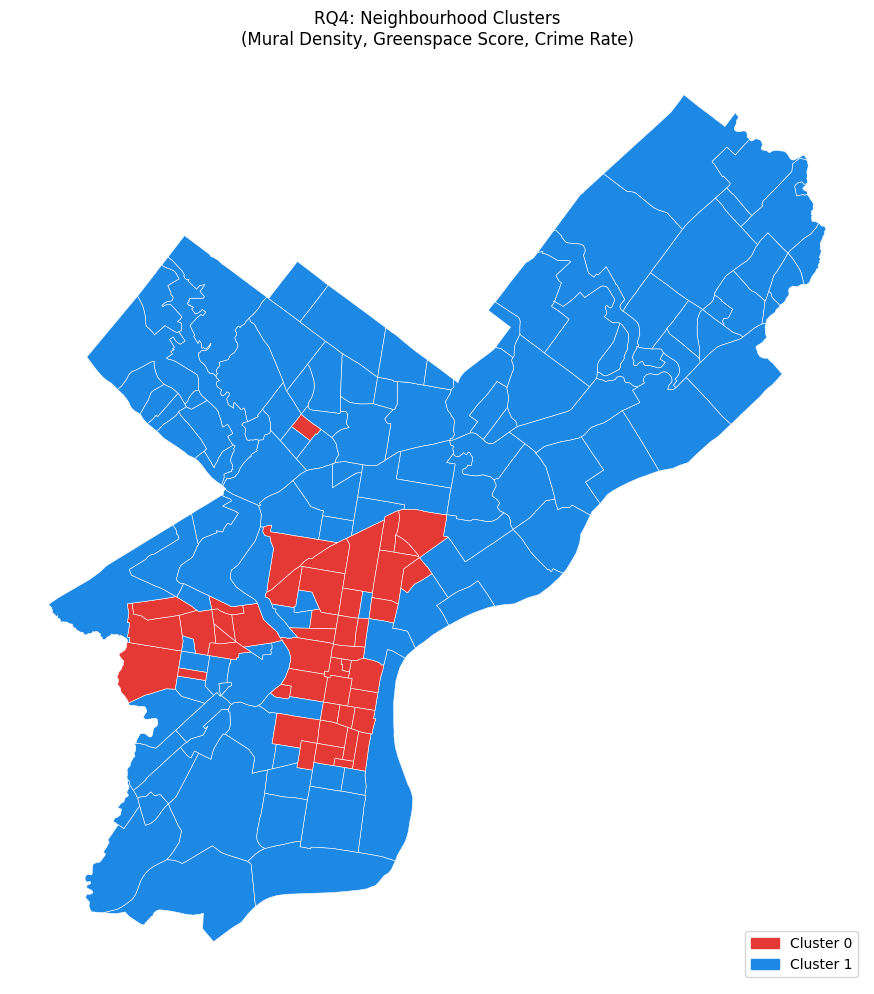

In [223]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df     = pd.read_csv('data/neighborhood_features.csv')
nb_gdf = gpd.read_file('data/maps/neighborhoods.geojson')

cluster_feats = ['mural_density', 'greenspace_score', 'crime_rate_total']
scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(df[cluster_feats].values)

# ── Elbow + Silhouette ────────────────────────────────────────────────────────
K_range = range(2, 11)
inertias, sil_scores = [], []
for k in K_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labs))

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f'Optimal K (max silhouette): {best_k}  (score={max(sil_scores):.3f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(K_range, inertias, 'o-', color='steelblue')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax2.plot(K_range, sil_scores, 'o-', color='darkorange')
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score'); ax2.legend()
fig.suptitle('RQ4: K-Means Cluster Selection', fontsize=12)
plt.tight_layout()
plt.savefig('figures/rq4_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final clustering ──────────────────────────────────────────────────────────
km_final   = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

profile_cols = cluster_feats + ['crime_rate_property', 'crime_rate_violent']
profile      = df.groupby('cluster')[profile_cols].mean().round(2)
print('\nCluster Profiles (mean values):\n')
print(profile.to_string())

# ── Choropleth cluster map ────────────────────────────────────────────────────
ndf          = nb_gdf.merge(df[['NAME', 'cluster']], on='NAME', how='left')
# Use a fixed palette so each cluster gets a distinct, consistent colour
palette      = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA',
                '#00ACC1', '#F4511E', '#6D4C41', '#3949AB']
cluster_cols = palette[:best_k]
cmap         = plt.cm.colors.ListedColormap(cluster_cols)

fig, ax = plt.subplots(figsize=(9, 10))
ndf['cluster'] = ndf['cluster'].astype(float)   # ensure numeric for vmin/vmax
ndf.plot(column='cluster', ax=ax, cmap=cmap,
         vmin=-0.5, vmax=best_k - 0.5,
         edgecolor='white', linewidth=0.4, legend=False)
patches = [mpatches.Patch(color=cluster_cols[i], label=f'Cluster {i}')
           for i in range(best_k)]
ax.legend(handles=patches, loc='lower right', fontsize=10)
ax.set_axis_off()
ax.set_title('RQ4: Neighbourhood Clusters\n(Mural Density, Greenspace Score, Crime Rate)',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/rq4_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()


### Results Summary

Consolidated metrics across all four research questions and model variants. This table populates from the variables computed in the cells above — run cells in order.

In [224]:
import pandas as pd

# Helper look-ups (avoid query() for columns with spaces or special chars)
def rq1_val(target, model, col):
    mask = (rq1_df['Target'] == target) & (rq1_df['Model'] == model)
    return rq1_df.loc[mask, col].values[0]

def rq2_val(crime, model, col):
    mask = (rq2_df['Crime Type'] == crime) & (rq2_df['Model'] == model)
    return rq2_df.loc[mask, col].values[0]

def rq2_pair(crime, model):
    f1    = rq2_val(crime, model, 'F1 (weighted)')
    kappa = rq2_val(crime, model, "Cohen's Kappa")
    return f"F1={f1}  K={kappa}"

def rq3m(crime):
    mask = moran_df['Crime Type'] == crime
    I = moran_df.loc[mask, "Moran's I"].values[0]
    p = moran_df.loc[mask, 'p-value'].values[0]
    return f"I={I}  p={p}"

def rq3s(model):
    mask = sl_df['Model'] == model
    rho = sl_df.loc[mask, 'Rho'].values[0]
    pr2 = sl_df.loc[mask, 'Pseudo R2'].values[0]
    return f"Rho={rho}  PseudoR2={pr2}"

summary_rows = [
    # RQ1
    {'RQ': 'RQ1', 'Method': 'OLS Regression',   'Model': 'A (Murals)',
     'Crime': 'Total',    'Metric': 'R2 (CV)',       'Value': rq1_val('Total', 'A (Murals only)', 'R2_CV')},
    {'RQ': 'RQ1', 'Method': 'OLS Regression',   'Model': 'B (Greenspace)',
     'Crime': 'Total',    'Metric': 'R2 (CV)',       'Value': rq1_val('Total', 'B (Greenspace only)', 'R2_CV')},
    {'RQ': 'RQ1', 'Method': 'OLS Regression',   'Model': 'C (Combined)',
     'Crime': 'Total',    'Metric': 'R2 (CV)',       'Value': rq1_val('Total', 'C (Combined)', 'R2_CV')},
    # RQ2
    {'RQ': 'RQ2', 'Method': 'Random Forest',    'Model': 'A (Murals)',
     'Crime': 'Property', 'Metric': 'F1 (weighted)', 'Value': rq2_val('Property', 'A (Murals only)', 'F1 (weighted)')},
    {'RQ': 'RQ2', 'Method': 'Random Forest',    'Model': 'C (Combined)',
     'Crime': 'Property', 'Metric': 'F1 / Kappa',   'Value': rq2_pair('Property', 'C (Combined)')},
    {'RQ': 'RQ2', 'Method': 'Random Forest',    'Model': 'C (Combined)',
     'Crime': 'Violent',  'Metric': 'F1 / Kappa',   'Value': rq2_pair('Violent', 'C (Combined)')},
    # RQ3
    {'RQ': 'RQ3', 'Method': "Moran's I",        'Model': '—',
     'Crime': 'Total',    'Metric': "I (p-value)",  'Value': rq3m('Total')},
    {'RQ': 'RQ3', 'Method': 'Spatial Lag (ML)', 'Model': 'A (Murals)',
     'Crime': 'Total',    'Metric': 'Rho/PseudoR2', 'Value': rq3s('A (Murals only)')},
    {'RQ': 'RQ3', 'Method': 'Spatial Lag (ML)', 'Model': 'C (Combined)',
     'Crime': 'Total',    'Metric': 'Rho/PseudoR2', 'Value': rq3s('C (Combined)')},
    # RQ4
    {'RQ': 'RQ4', 'Method': 'K-Means',          'Model': '—',
     'Crime': 'All',      'Metric': 'Silhouette',   'Value': f'K={best_k}  Sil={max(sil_scores):.3f}'},
]

summary_df = pd.DataFrame(summary_rows)
print('\n=== FULL RESULTS SUMMARY ===\n')
print(summary_df[['RQ', 'Method', 'Model', 'Crime', 'Metric', 'Value']].to_string(index=False))



=== FULL RESULTS SUMMARY ===

 RQ           Method          Model    Crime        Metric                       Value
RQ1   OLS Regression     A (Murals)    Total       R2 (CV)                       -0.86
RQ1   OLS Regression B (Greenspace)    Total       R2 (CV)                       -1.62
RQ1   OLS Regression   C (Combined)    Total       R2 (CV)                       -0.73
RQ2    Random Forest     A (Murals) Property F1 (weighted)                        0.79
RQ2    Random Forest   C (Combined) Property    F1 / Kappa            F1=0.805  K=0.61
RQ2    Random Forest   C (Combined)  Violent    F1 / Kappa           F1=0.766  K=0.535
RQ3        Moran's I              —    Total   I (p-value)           I=0.5412  p=0.001
RQ3 Spatial Lag (ML)     A (Murals)    Total  Rho/PseudoR2 Rho=0.5277  PseudoR2=0.5676
RQ3 Spatial Lag (ML)   C (Combined)    Total  Rho/PseudoR2 Rho=0.5073  PseudoR2=0.5684
RQ4          K-Means              —      All    Silhouette              K=2  Sil=0.521
